In [1]:
import numpy as np
import psutil
import time
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection, LineCollection
from PIL import Image

In [2]:
# Book code (based on Bridson's description), modified for my terminology

def brid_sampling(w=1.0, h=1.0, r=0.025, k=30):
    """
    
    Bridson apparently suggests $k=30$, but maybe start with $k=4$ for speed.  

    Bridson's paper says only remove frontier nodes after k failed tries.
    Here, we implicitly assume k is high enough to sample the annulus well.  
    So we immediately remove the frontier node and skip having an if-block.

    Code also has a lookup table N, for speed. 
    Per grid position (i, j), stores all cells n-steps away (default n=2).
    
    """
    def squared_distance(p0, p1):
        """Euclidean distance that is faster than linalg (somehow)"""
        return (p0[0]-p1[0])**2 + (p0[1]-p1[1])**2 
        
    def random_point_around(point, k=1):
        """Generate k candidates w/ random polar coordinates (for annulus)"""
        R = np.random.uniform(r, 2*r, k)
        T = np.random.uniform(0, 2*np.pi, k)
        P = np.empty((k, 2))
        P[:, 0] = point[0]+R*np.sin(T)
        P[:, 1] = point[1]+R*np.cos(T)
        return P
    
    def neighborhood(shape, index, n=2):
        """For index=(row, col), return all cells 1 to n steps away"""
        row, col = index
        row0, row1 = max(row-n, 0), min(row+n+1, shape[0])
        col0, col1 = max(col-n, 0), min(col+n+1, shape[1])
        I = np.dstack(np.mgrid[row0:row1, col0:col1])
        I = I.reshape(I.size//2, 2).tolist()
        I.remove([row, col]) # exclude the cell itself
        return I
    
    def in_neighborhood(cand):
        """Check if a candidate IS too close to any other accepted point."""
        i, j = int(cand[0]/cellsize), int(cand[1]/cellsize)
        if accept[i, j]: 
            return True # cell already occupied
        for (i, j) in N[(i, j)]:
            if accept[i, j] and squared_distance(cand, pos[i, j]) < r_sq:
                return True
        return False
        
    def add_point(cand):
        """Add valid candidate to the frontier and set of accepted points."""
        frontier.append(cand)
        i, j = int(cand[0]/cellsize), int(cand[1]/cellsize)
        pos[i, j], accept[i, j] = cand, True

    cellsize = r/np.sqrt(2)
    rows = int(np.ceil(w/cellsize))
    cols = int(np.ceil(h/cellsize))

    r_sq = r*r
    
    pos = np.zeros((rows, cols, 2), dtype=np.float32)
    accept = np.zeros((rows, cols), dtype=bool)

    # Cache generation for neighborhood
    N = {}
    for i in range(rows):
        for j in range(cols):
            N[(i, j)] = neighborhood(accept.shape, (i, j), 2)
            
    # Steps 2-3
    frontier = [] 
    add_point((np.random.uniform(w), np.random.uniform(h)))
    while len(frontier):
        i = np.random.randint(len(frontier))
        point = frontier[i]
        del frontier[i]
        k_cands = random_point_around(point, k)
        for cand in k_cands:
            if (0<=cand[0]<w) and (0<=cand[1]<h) and not in_neighborhood(cand):
                add_point(cand)
    return pos[accept]

# common test sample for Voronoi work below
test_sample = brid_sampling() 

# PART II - Voronoi Tessellation

## Book Code

The next step is to make the associated [Voronoi diagram](https://en.wikipedia.org/wiki/Voronoi_diagram) for the sampled points.  
Given a set of points or "seeds" across a region, the Voronoi diagram partitions the region into cells associated to a particular seed.  
Each Voronoi cell consists of all parts of the region closer to that seed than any other seed.  

When the book did this, they went for the fast option immediately - I guess it's just not that relevant to the lesson.  
In this case, that means first making a [Delaunay triangulation](https://en.wikipedia.org/wiki/Delaunay_triangulation).  
Given a set of points, construct a set of triangles (read: triplets of points) s.t. no triangle contains other points.  
Once you do that, the triangles can be inscribed into circles - these are the circumcircles.  
The centers of the circumcircles turn out to be the [boundaries of Voronoi cells](https://en.wikipedia.org/wiki/Delaunay_triangulation#Relationship_with_the_Voronoi_diagram). 

If you're familiar with the terms, the slow part is the triangulation itself (time complexity $O(n\log{(n)})$), which is still pretty good.   
Even better, there is already code to do Delaunay triangulation: [matplotlib's tri.Triangulation](https://matplotlib.org/stable/api/tri_api.html)  
While I have no doubt you could make your own triangulator in Python, you will (almost) always get faster results from `numpy` and `matplotlib`.  
They have `C++` on their side which is typically $100 \times$ faster, so just use it.  

In [3]:
# Book code (copied directly) 

def circumcircle(P1,P2,P3):
    """ 
    This compute the center and radius of the (unique) circle that passes
    through points P1, P2 & P3.

    Adapted from:
    http://local.wasp.uwa.edu.au/~pbourke/geometry/circlefrom3/Circle.cpp
    """
    delta_a = P2 - P1
    delta_b = P3 - P2
    epsilon = 0.000000001
    if np.abs(delta_a[0]) <= epsilon and np.abs(delta_b[1]) <= epsilon:
        center_x = 0.5*(P2[0] + P3[0])
        center_y = 0.5*(P1[1] + P2[1])
    else:
        aSlope = delta_a[1]/delta_a[0]
        bSlope = delta_b[1]/delta_b[0]
        if np.abs(aSlope-bSlope) <= epsilon:
            return None
        center_x= (aSlope*bSlope*(P1[1] - P3[1]) + bSlope*(P1[0] + P2 [0]) \
                        - aSlope*(P2[0]+P3[0]) )/(2* (bSlope-aSlope) )
        center_y = -1*(center_x - (P1[0]+P2[0])/2)/aSlope +  (P1[1]+P2[1])/2;
    radius = np.sqrt( (center_x - P1[0])**2+(center_y - P1[1])**2)
    return center_x, center_y, radius

def voronoi(X,Y):
    """
    This compute the Voronoi diagram of points X,Y

    Return the Voronoi cells (as a list of points), Delaunay triangles (as a
    list of indices in X and Y) & Delaunay circles as list of (x,y,radius).
    """
    
    P = np.zeros((X.size,2))
    P[:,0] = X
    P[:,1] = Y

    D = matplotlib.tri.Triangulation(X,Y)
    T = D.triangles
    n = T.shape[0]
    C = np.zeros((n,3))

    # Get circle for each triangle, center will be a voronoi cell point
    cells = []
    for i in range(X.size):
        cells.append( list() )
    for i in range(n):
        C[i] = circumcircle(P[T[i,0]],P[T[i,1]],P[T[i,2]])
        x,y,r = C[i]
        cells[T[i,0]].append( (x,y) )
        cells[T[i,1]].append( (x,y) )
        cells[T[i,2]].append( (x,y) )

    # Reordering cell points in trigonometric way
    for i,cell in enumerate(cells):
        xy = np.array(cell)
        I = np.argsort(np.arctan2(xy[:,1]-Y[i],xy[:,0]-X[i]))
        cell = xy[I].tolist()
        cell.append(cell[0])
        cells[i] = cell
    return cells, D.triangles, C


In [4]:
# Speed test for book code (baseline)
X = np.random.random(len(test_sample))
Y = np.random.random(len(test_sample))
%time segments = voronoi(X,Y)

CPU times: user 16.5 ms, sys: 842 µs, total: 17.3 ms
Wall time: 19.1 ms


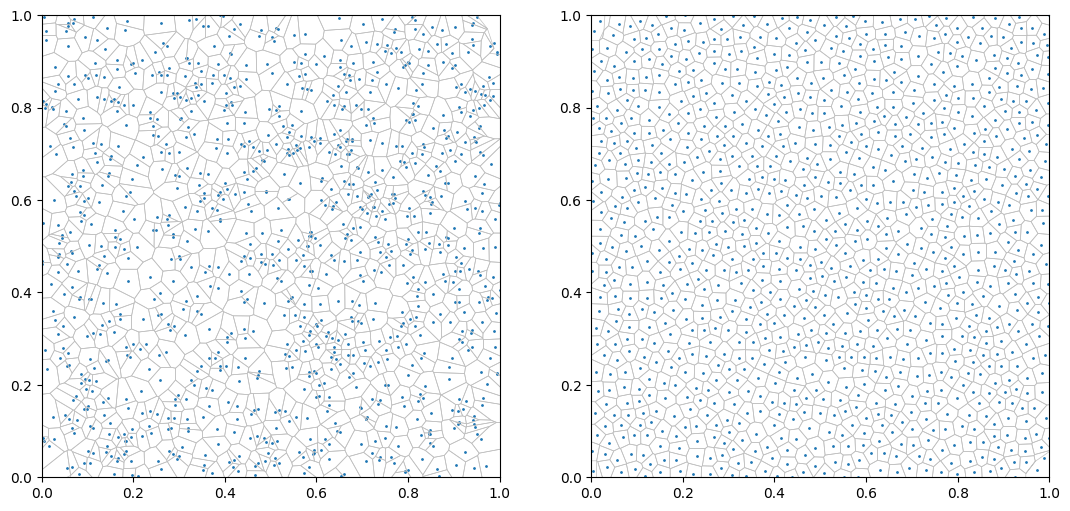

In [5]:
# Plot comparison of random to blue noise
# Should make this a loop eventually
fig, axs = plt.subplots(1, 2, figsize=(13, 6))

X = np.random.random(len(test_sample))
Y = np.random.random(len(test_sample))
segments = voronoi(X,Y)
axs[0].scatter(X,Y, s=1)
lines = LineCollection(segments[0], color='0.75', linewidth=0.5)
axs[0].add_collection(lines)
axs[0].set_xlim(0, 1)
axs[0].set_ylim(0, 1)

X, Y = test_sample[:, 0], test_sample[:, 1]
segments = voronoi(X,Y)
axs[1].scatter(X,Y, s=1)
lines = LineCollection(segments[0], color='0.75', linewidth=0.5)
axs[1].add_collection(lines)
axs[1].set_xlim(0, 1)
axs[1].set_ylim(0, 1)

plt.show()

## Brute Force Voronoi

Pretend we didn't know that much about computational geometry, and *didn't* know Delaunay triangulation.  
We can still get a Voronoi diagram from the definition.  

The simplest possible method:
1. Initialize the plane as an $n\times m$ array with some placeholder value like $-1$.  
1. For each point in the array:
    1. Calculate the distance to all $k$ seeds.
    1. Replace the value in the current point with the index of the seed with the smallest distance.
  


In [6]:
def voronoi_bf(X, Y, res=10, shuffle=True): 
    """
    Default resolution on domain [0, 1] is 3 decimals.
    Takes ~10 seconds for 1000 seeds.
    """
    x = np.linspace(0, 1, 2**res)
    y = np.linspace(0, 1, 2**res)
    xx, yy = np.meshgrid(x, y)

    # shuffling for plot purposes
    if shuffle:
        p = np.random.permutation(len(X))
        X0, Y0 =  X[p], Y[p]
    
    dists = np.zeros((len(yy), len(xx), len(X)))
    for i in range(len(X)):
        dists[:, :, i] = np.sqrt((xx-X0[i])**2 + (yy-Y0[i])**2)
    #print("extent=[0, 1, 1, 0]")
    
    return np.argmin(dists, axis=2)


In [7]:
# Speed test of brute force method
X = np.random.random(len(test_sample))
Y = np.random.random(len(test_sample))
%time out = voronoi_bf(X,Y)

CPU times: user 9.65 s, sys: 2.09 s, total: 11.7 s
Wall time: 12 s


In [8]:
X, Y = test_sample[:, 0], test_sample[:, 1]
segments_bf = voronoi_bf(X,Y)

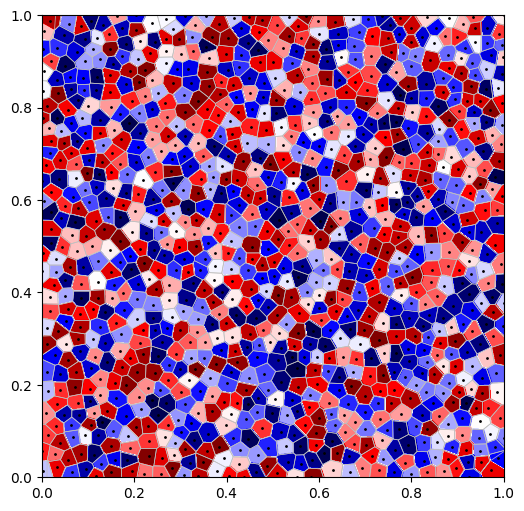

In [9]:
# Our cells should properly color the book lining
plt.figure(figsize=(13, 6))

axs = plt.gca()
plt.imshow(segments_bf, extent=[0, 1, 1, 0], cmap="seismic")
X, Y = test_sample[:, 0], test_sample[:, 1]
plt.scatter(X,Y, s=1, color='k')
lines = LineCollection(segments[0], color='0.75', linewidth=0.5)
axs.add_collection(lines)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

Close enough.

## Vectorizing Brute Force Method

Now that we know numpy exists, we may as well try and speed up the code by vectorizing it to get rid of the `for`-loop.  
The most straightforward way to do that is to just use more space, turning the meshgrid and seed positions into 3-d arrays.  

In [10]:
def voronoi_np(X, Y, res=10, shuffle=True): 
    """
    Numpy vectorized version of brute force method. 
    Would recommend NOT running the test cells for this. 
    This is just for demo of thrashing. 
    """
    x = np.linspace(0, 1, 2**res)
    y = np.linspace(0, 1, 2**res)
    xx, yy = np.meshgrid(x, y)

    # shuffling for plot purposes
    if shuffle:
        p = np.random.permutation(len(X))
        X, Y =  X[p], Y[p]
        
    X1 = X[np.newaxis, np.newaxis, :]
    Y1 = Y[np.newaxis, np.newaxis, :]

    xx_exp = xx[:, :, np.newaxis]
    yy_exp = yy[:, :, np.newaxis]

    # Compute distances
    dists = np.sqrt((xx_exp - X1)**2 + (yy_exp - Y1)**2)
    return np.argmin(dists, axis=2)

In [11]:
# Speed test of vectorized BF code
X = np.random.random(len(test_sample))
Y = np.random.random(len(test_sample))
%time out = voronoi_np(X,Y)

CPU times: user 4.94 s, sys: 15 s, total: 19.9 s
Wall time: 1min 24s


In [12]:
X, Y = test_sample[:, 0], test_sample[:, 1]
segments_np = voronoi_np(X,Y)

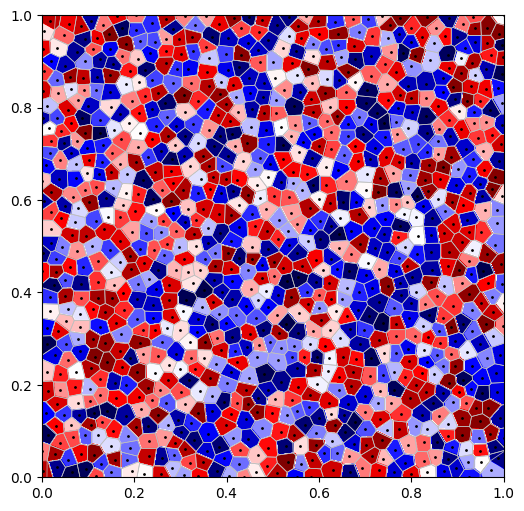

In [13]:
# Check the coloring is still good
plt.figure(figsize=(13, 6))

axs = plt.gca()
plt.imshow(segments_np, extent=[0, 1, 1, 0], cmap="seismic")
X, Y = test_sample[:, 0], test_sample[:, 1]
plt.scatter(X,Y, s=1, color='k')
lines = LineCollection(segments[0], color='0.75', linewidth=0.5)
axs.add_collection(lines)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

You may at this point be thinking "WTF, I thought vectorization was supposed to be faster?"  

**Short Answer:**  
It *usually* is - an exception is when the variables start getting *very* large.  

**Long Answer:**  
What is happening is called [thrashing](https://en.wikipedia.org/wiki/Thrashing_(computer_science)).  
Our vectorized code is currently turning a $10^3 \times 10^3$ distance array into a roughly $10^3 \times 10^3 \times 10^3$ volume.  
Checking the size with `nbytes`, this is about 8 GB of memory.  

My available RAM is only ~10 GB, the array barely fits.  
When you try to do something (like arithmetic) on the array, it tries to load more variables of similar size.  
They can't all fit on RAM, so the computer needs to start working with disk memory.  
Accessing disk memory is horrendously slow compared to using RAM, so you want to avoid that. 

In fact if you compare the performance on smaller cases, either with worse resolution or fewer seeds, the vectorized version *is* faster.  
It's only when the number of grid points or seeds (or both) are sufficiently large that the vectorized version does worse.  
But when the vectorized *does* hit that region, it's hitting a brick wall.  

In [14]:
# Memory Checks

arr = np.zeros((1000, 1000, 1000), dtype=np.float64)
print(f"Array size: {arr.nbytes / (1024*10**6):.2f} GB")
print()
mem = psutil.virtual_memory()
print(f"Total RAM: {mem.total / 1024**3:.2f} GB")
print(f"Available RAM: {mem.available / 1024**3:.2f} GB")
print(f"Used RAM: {mem.used / 1024**3:.2f} GB")


Array size: 7.81 GB

Total RAM: 16.00 GB
Available RAM: 13.51 GB
Used RAM: 1.70 GB


In [15]:
# Test performance of vectorizer with higher resolution
seeds = 10
allRes = np.arange(3, 10+1)

res_times_bf = np.zeros(len(allRes))
res_times_np = np.zeros(len(allRes))

for i in range(len(allRes)):
    r = allRes[i]
    X = np.random.random(2**seeds)
    Y = np.random.random(2**seeds)
    
    start = time.time()
    a = voronoi_bf(X,Y, res = r)
    stop = time.time()
    res_times_bf[i] = stop - start

    start = time.time()
    a = voronoi_np(X,Y, res = r)
    stop = time.time()
    res_times_np[i] = stop - start


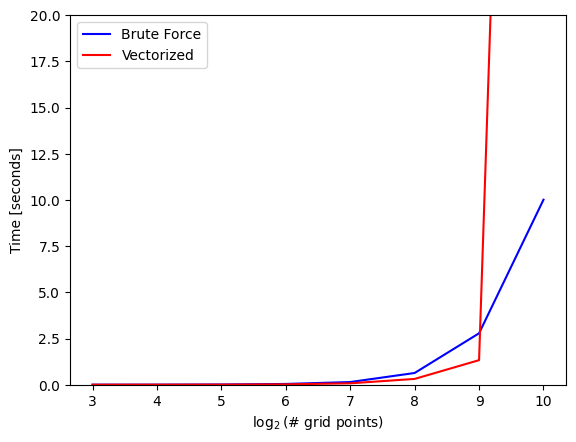

In [16]:
plt.figure()
plt.plot(allRes, res_times_bf, label='Brute Force', color='b')
plt.plot(allRes, res_times_np, label='Vectorized', color='r')
plt.legend()
plt.xlabel(r'$\log_{2}$(# grid points)')
plt.ylabel('Time [seconds]')
plt.ylim(0, 20)

plt.show()

In [17]:
# Test performance of vectorizer with more seeds
allSeeds = np.arange(3, 10+1)
r = 10

seed_times_bf = np.zeros(len(allSeeds))
seed_times_np = np.zeros(len(allSeeds))

for i in range(len(allSeeds)):
    seeds = allSeeds[i]
    X = np.random.random(2**seeds)
    Y = np.random.random(2**seeds)
    
    start = time.time()
    a = voronoi_bf(X,Y, res = r)
    stop = time.time()
    seed_times_bf[i] = stop - start

    start = time.time()
    a = voronoi_np(X,Y, res = r)
    stop = time.time()
    seed_times_np[i] = stop - start


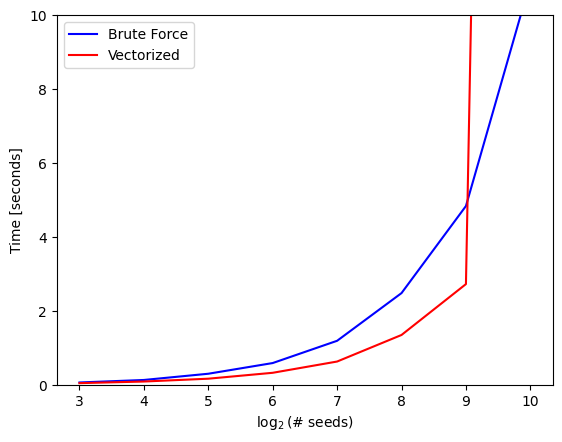

In [18]:
plt.figure()
plt.plot(allSeeds, seed_times_bf, label='Brute Force', color='b')
plt.plot(allSeeds, seed_times_np, label='Vectorized', color='r')
plt.legend()
plt.xlabel(r'$\log_{2}$(# seeds)')
plt.ylabel('Time [seconds]')
plt.ylim(0, 10)

plt.show()

## Chunking

The underlying problem is the matrix I'm working with is too big.  
I clearly don't want to sacrifice resolution, and I want the final piece to have a certain density of points, so I can't touch the array sizes.  
But I don't actually have to work with the entire matrix at once.  

I could work on smaller parts of the matrix at a time, get the correct tessellation in that part, then log the result.  
This will still require a `for`-loop, there's no way around it.  
What I can do is process a set of elements per iteration, and speed things up by vectorizing that portion.  

In other words, I am "chunking" an $n \times m$ array into blocks of $h \times w$ sub-arrays, where there are around $\frac{n}{h} \times \frac{w}{m}$ sub-arrays to process.  
Visiting all sub-arrays is not vectorized (it's in a `for`-loop), but the individual processing of each sub-array is.  


In [19]:
def voronoi_np_v2(X, Y, res=10, shuffle=True, h_chunk=7, w_chunk=7): 
    """
    Numpy vectorized version 2.
    Adds chunking of the spatial dimensions to avoid memory limits.
    """
 
    x = np.linspace(0, 1, 2**res)
    y = np.linspace(0, 1, 2**res)
    xx, yy = np.meshgrid(x, y)

    # shuffling for plot purposes
    if shuffle:
        p = np.random.permutation(len(X))
        X, Y =  X[p], Y[p]
        
    # Initialize distances as empty matrix
    dists = np.empty((len(y), len(x), len(X)), dtype=np.float64)

    # Work in spatial chunks
    for h_start in range(0, len(x), 2**h_chunk):
        h_end = min(h_start + 2**h_chunk, len(x))
        for w_start in range(0, len(y), 2**w_chunk):
            w_end = min(w_start + 2**w_chunk, len(y))

            # Slice current chunk of the grid
            xx_chunk = xx[h_start:h_end, w_start:w_end]
            yy_chunk = yy[h_start:h_end, w_start:w_end]

            # Compute distances from all centers for this spatial chunk
            dx = xx_chunk[:, :, np.newaxis] - X[np.newaxis, np.newaxis, :]
            dy = yy_chunk[:, :, np.newaxis] - Y[np.newaxis, np.newaxis, :]
            d_chunk = np.sqrt(dx**2 + dy**2)

            # Store in output array
            dists[h_start:h_end, w_start:w_end, :] = d_chunk
    return np.argmin(dists, axis=2)

In [20]:
# Test performance of chunker with higher resolution
seeds = 10
allRes = np.arange(3, 10+1)

res_times_bf = np.zeros(len(allRes))
res_times_np2 = np.zeros(len(allRes))

for i in range(len(allRes)):
    r = allRes[i]
    X = np.random.random(2**seeds)
    Y = np.random.random(2**seeds)
    
    start = time.time()
    a = voronoi_bf(X,Y, res = r)
    stop = time.time()
    res_times_bf[i] = stop - start

    start = time.time()
    a = voronoi_np_v2(X,Y, res = r)
    stop = time.time()
    res_times_np2[i] = stop - start


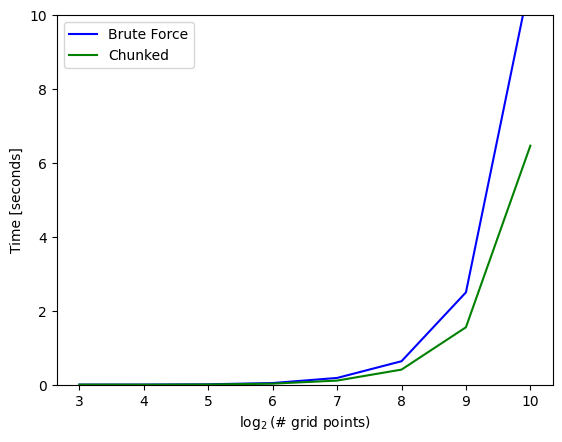

In [21]:
plt.figure()
plt.plot(allRes, res_times_bf, label='Brute Force', color='b')
plt.plot(allRes, res_times_np2, label='Chunked', color='g')
plt.legend()
plt.xlabel(r'$\log_{2}$(# grid points)')
plt.ylabel('Time [seconds]')
plt.ylim(0, 10)

plt.show()

In [22]:
# Test performance of chunker with more seeds
allSeeds = np.arange(3, 10+1)
r = 10

seed_times_bf = np.zeros(len(allSeeds))
seed_times_np2 = np.zeros(len(allSeeds))

for i in range(len(allSeeds)):
    seeds = allSeeds[i]
    X = np.random.random(2**seeds)
    Y = np.random.random(2**seeds)
    
    start = time.time()
    a = voronoi_bf(X,Y, res = r)
    stop = time.time()
    seed_times_bf[i] = stop - start

    start = time.time()
    a = voronoi_np_v2(X,Y, res = r)
    stop = time.time()
    seed_times_np2[i] = stop - start


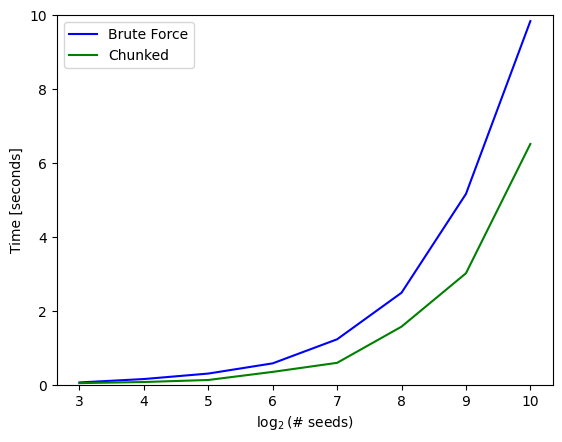

In [23]:
plt.figure()
plt.plot(allSeeds, seed_times_bf, label='Brute Force', color='b')
plt.plot(allSeeds, seed_times_np2, label='Chunked', color='g')
plt.legend()
plt.xlabel(r'$\log_{2}$(# seeds)')
plt.ylabel('Time [seconds]')
plt.ylim(0, 10)

plt.show()

And there we go, we now have vectorized code that will run faster than the brute force method.  
Not much faster, but faster.  

**Moral of the story:** Look, vectorizing things helps.  
But the fastest code relies on good algorithms, math, and lower-level implementation.  
There is no shame in using a library that does exactly what you're trying to do - solve dumb problems with overkill.  

That said, our code the benefit that only a single line is used for calculating distances.  
That means we can easily switch it out for distances (read: [metrics](https://en.wikipedia.org/wiki/Metric_space#Definition)) other than the Euclidean one, and get a new tessellation.  
You'll learn about a few alternative distances in your DMW class, but a common one is the [Manhattan distance](https://en.wikipedia.org/wiki/Taxicab_geometry). 

# Extra: Fortune's Algorithm 

Something you'll begrudgingly, but eventually, accept about programming: 
> Bad algorithms on good systems will usually lose to good algorithms on bad systems, especially for large problems.

We can optimize the actual code execution as much as we want, but our ultimate bottleneck is the inefficiency of the algorithm.  

In this case, we're calculating the distance of each point in the domain to **every** seed.  
There's really no need for this.  
Points on one end of the domain are unlikely to be in the cell of seeds on the other end.  
Furthermore, once the entire boundary of a cell has been found, the associated seed is effectively dead and should not be checked for future points. 

Implementing these ideas in our approach leads to [Fortune's algorithm](https://en.wikipedia.org/wiki/Fortune%27s_algorithm).  
An efficient code implementation is somewhat out of scope because it requires knowledge of data structures like binary search trees and priority queues.  
If you'd like though, you could check out [foronoi](https://voronoi.readthedocs.io/en/latest/index.html) which is exactly a Voronoi tessellator with Fortune's algorithm.  

The underlying algorithm is straightforward though, as shown in the [Wikipedia animation](https://en.wikipedia.org/wiki/Fortune%27s_algorithm#/media/File:Fortunes-algorithm-slowed.gif).  
It tracks 2 lines: a sweep line and a beach line.  
The sweep line is a straight line that moves in one direction (say left to right) and tracks all the currently known seeds.  
The beach line trails behind it, and tracks the set of points which (for the current sweep line) must be part of a cell of a known seed.  
It's made of parabolas, because parabolas show all points equidistant to the sweep line where a seed crossed it.  
Between the two lines are points which could be in the cell of eithe a known seed, or an unknown seed ahead of the beach line.  
Where two parabolas intercept defines the edge of a cell, and if the parabola is completely enclosed by another its cell must be full.  
By tracking which parabolas are active, we can include and exclude seeds efficiently from the cell filling. 